# Задача кластеризации

In [807]:
import numpy as np              # Одномерные и многомерные массивы (array)
import pandas as pd             # Таблицы и временные ряды (dataframe, series)
import matplotlib.pyplot as plt # Научная графика
import seaborn as sns           # Еще больше красивой графики для визуализации данных
import sklearn                  # Алгоритмы машинного обучения

# 0. Описание задачи
Необходимо решить задачу кластеризации с датасетом "Coffee_Sales _Dataset", используя методы: **KMeans**, **DBSCAN** и Agglomerative Clustering.
Использовать PCA для понижения размерности и визуализировать полученные данные.
## В чем отличие?
Задача кластеризации основана на разбиении множества объектов на подмножества по некоторым признакам.
В отличии от предыдущей задачи (задача регрессии), мы не ставим цель угодать значение Y по некоторому X.

# 1. Загрузка данных
Данные данного датасета взяты с сайта https://www.kaggle.com. Название датасета: "Coffee_Sales _Dataset".

In [808]:
url = "https://raw.githubusercontent.com/Korobokkk/Machine_learning/master/Coffe_sales.csv"
data_raw = pd.read_csv(url)

Смотрим размеры и вид таблицы.

In [809]:
data_raw.shape

(3547, 11)

In [810]:
data_raw

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,3/1/2024,15:50.5
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,3/1/2024,19:22.5
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,3/1/2024,20:18.1
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,3/1/2024,46:33.0
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,3/1/2024,48:14.6
...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,3/23/2025,34:54.9
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,3/23/2025,43:37.4
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,3/23/2025,44:16.9
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,3/23/2025,47:28.7


Основная информация о датасете.

In [811]:
data_raw.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


Убедились в отсутствии пропущенных значений.
Коротко об основных признаках:
-   `coffee_name` - название кофе.('Americano', 'Americano with Milk', 'Cappuccino', 'Cocoa','Cortado', 'Espresso', 'Hot Chocolate', 'Latte').
-   `Time_of_Day` - время суток ('Afternoon', 'Morning', 'Night').
-  `Weekday` -день недели ('Fri', 'Mon', 'Sat', 'Sun', 'Thu', 'Tue', 'Wed').Есть числовой аналог
- `Month_name` -месяц в который прибрели продукт ('Apr', 'Aug', 'Dec', 'Feb', 'Jan', 'Jul', 'Jun', 'Mar',
                  'May', 'Nov', 'Oct', 'Sep'). Есть числовой аналог
- `money`- стоимость оплаченного продукта.  
- `Time` -время приобретения (утро день, вечер, ночь)

# 2. Обработка данных датасета
Избавимся от бесполезных и повторяющихся признаков.

Заметим что `cash_type` всегда одинаковый

In [812]:
data_raw['cash_type']= data_raw['cash_type'].astype('category')
data_raw['cash_type'].dtype

CategoricalDtype(categories=['card'], ordered=False, categories_dtype=object)

In [813]:
data_raw.drop('cash_type', axis=1, inplace=True)

`Weekday` и `Month_name` уже имеют копии в численных версиях. Тут важно, что представление признаков в инкрементном числовом виде (напр. для `Month_name` 1-12 может плохо повлиять на масштабируемость и конечный результат, ведь этот признак может 'задавить', к примеру, `Time_of_Day`).
Избавимся от числовых клонов и чуть позже переведем данные признаки в числовой вид с помощью One-Hot Encoding.


In [814]:
data_raw.drop('Weekdaysort', axis=1 , inplace=True)
data_raw.drop('Monthsort', axis=1 , inplace=True)

`Time_of_Day` является более семантически информативным параметром по сравнению с `hour_of_day`. Так как эти два признака сильно коррелируют между собой, избавимся от `hour_of_day`.

Также удалим признаки `Date` и `Time`.
- Значение `Date` сильно зависит от месяца. Хотя оно может фиксировать аномальные всплески активности, например, в праздничные дни, для кластеризации оно не будет вносить значимого вклада.
- Аналогично для `Time` в совокупности с `Time_of_Day`.

In [815]:
data_raw.drop('hour_of_day', axis=1, inplace=True)
data_raw.drop('Date', axis=1 , inplace=True)
data_raw.drop('Time', axis=1 , inplace=True)

В прошлой работе я вывел, что признак `money`практически полностью определяется двумя признаками `Month_name` и `coffee_name`. Значит он бесполезен.

In [816]:
data_raw.drop('money', axis=1, inplace=True)

# 2.1 Доработка в обработке данных
После использования PCA для оставшихся признаков был получен большой разброс между элементами кластера. Попробуем убрать `Weekday` из data_raw и повлиять на последующие результаты

In [817]:
data_raw.drop('Weekday', axis=1, inplace=True)

Вместо базового использования месяцев будем использовать сезоны, для понижения размерности при кластеризации

In [818]:
season = {
  'Dec': 'Winter', 'Jan': 'Winter', 'Feb': 'Winter',
  'Mar': 'Spring', 'Apr': 'Spring', 'May': 'Spring',
  'Jun': 'Summer', 'Jul': 'Summer', 'Aug': 'Summer',
  'Sep': 'Aurumn', 'Oct': 'Aurumn', 'Nov': 'Aurumn'
}
data_raw['Season'] = data_raw['Month_name'].map(season)
data_raw.drop('Month_name', axis= 1, inplace= True)

Теперь аналогично с кофе.

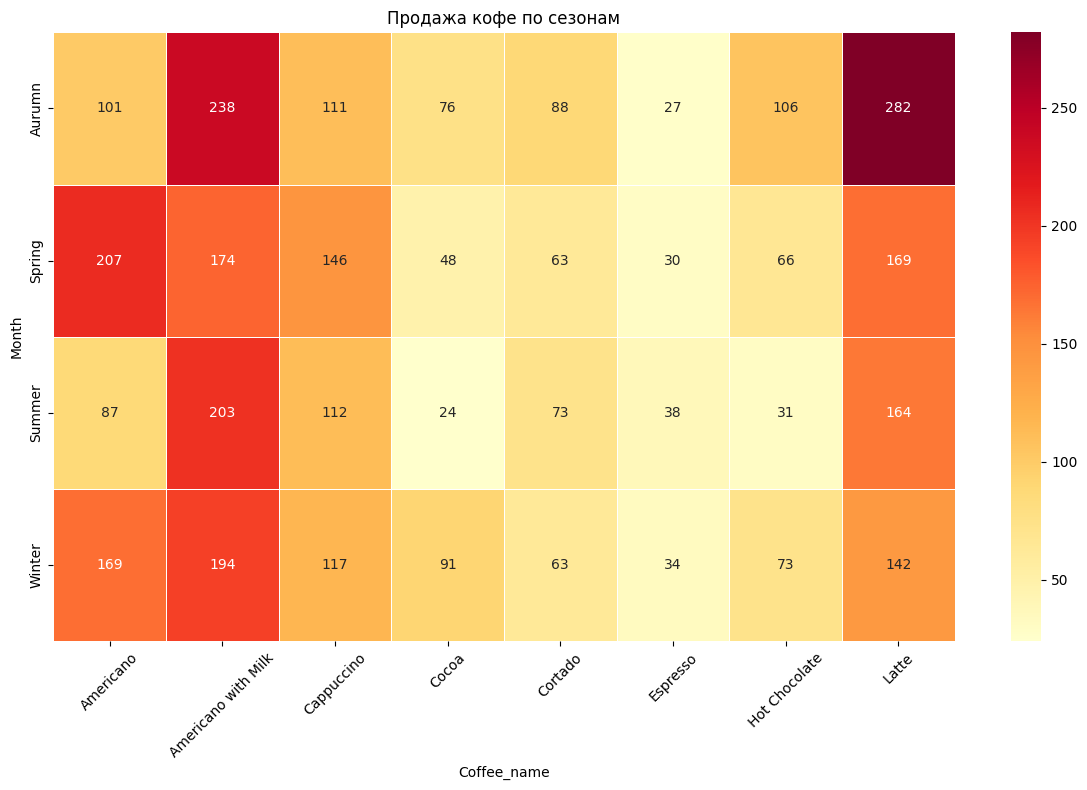

In [819]:
plt.figure(figsize=(12, 8))
monthly_coffee = data_raw.groupby(['Season', 'coffee_name'], observed=False).size().unstack(fill_value=0)

sns.heatmap(monthly_coffee,
           annot=True,
           fmt='d',
           cmap='YlOrRd',
           linewidths=0.5)
plt.title('Продажа кофе по сезонам')
plt.xlabel('Coffee_name')
plt.ylabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [820]:
Type_of_coffee={
    'Americano': 'coffee', 'Espresso': 'coffee',
    'Americano with Milk': 'coffee with milk', 'Cappuccino': 'coffee with milk', 'Cortado': 'coffee with milk', 'Latte': 'coffee with milk',
    'Cocoa': 'chocolate', 'Hot Chocolate': 'chocolate'
}
data_raw['Type_of_coffee'] = data_raw['coffee_name'].map(Type_of_coffee)
data_raw.drop('coffee_name', axis= 1, inplace= True)

Оставшиеся признаки:

In [821]:
data_raw.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Time_of_Day     3547 non-null   object
 1   Season          3547 non-null   object
 2   Type_of_coffee  3547 non-null   object
dtypes: object(3)
memory usage: 83.3+ KB


# 3. Перевод категориальных признаков в числовые при помощи One-Hot Encoding.

In [822]:
data_encoded = pd.get_dummies(
    data_raw,
    columns=['Type_of_coffee', 'Time_of_Day', 'Season']
)

In [823]:
data_encoded.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Type_of_coffee_chocolate         3547 non-null   bool 
 1   Type_of_coffee_coffee            3547 non-null   bool 
 2   Type_of_coffee_coffee with milk  3547 non-null   bool 
 3   Time_of_Day_Afternoon            3547 non-null   bool 
 4   Time_of_Day_Morning              3547 non-null   bool 
 5   Time_of_Day_Night                3547 non-null   bool 
 6   Season_Aurumn                    3547 non-null   bool 
 7   Season_Spring                    3547 non-null   bool 
 8   Season_Summer                    3547 non-null   bool 
 9   Season_Winter                    3547 non-null   bool 
dtypes: bool(10)
memory usage: 34.8 KB


# 4. Масштабирование
Полученный набор данных на всякий случай масштабируем. Это стандартная практика, которая применяется, чтобы не столкнуться с проблемами при кластеризации на следующих этапах.

In [824]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_encoded)

In [825]:
scaled_df = pd.DataFrame(X_scaled, columns=data_encoded.columns)

scaled_df.describe().loc[['mean', 'std']]

,Type_of_coffee_chocolate,Type_of_coffee_coffee,Type_of_coffee_coffee with milk,Time_of_Day_Afternoon,Time_of_Day_Morning,Time_of_Day_Night,Season_Aurumn,Season_Spring,Season_Summer,Season_Winter
mean,1.602577e-17,4.407088e-17,1.442320e-16,1.201933e-17,8.613853e-17,-4.006443e-18,-2.083351e-16,0.000000,2.564124e-16,1.282062e-16
std,1.000141e+00,1.000141e+00,1.000141e+00,1.000141e+00,1.000141e+00,1.000141e+00,1.000141e+00,1.000141,1.000141e+00,1.000141e+00


# 5. Алгоритмы кластеризации


Фиксируем матрицу признаков

In [826]:
X= X_scaled

## 5.1 Метод K-means

Перед нами стоит задача выбрать оптимальное количество кластеров для KMeans. Для этого используем метод Локтя.

В чем суть метода:
- KMeans минимизирует Inertia — сумму квадратов расстояний от точек до центров своих кластеров.
- Если кластеров мало, Inertia большая.
- С увеличением k Inertia уменьшается, потому что кластеры становятся более «узкими».
- Но после определённого k снижение становится незначительным — новые кластеры просто дробят существующие и не имеют практического смысла.

In [827]:
from sklearn.cluster import KMeans

inertia = []
for k in range(2, 30):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

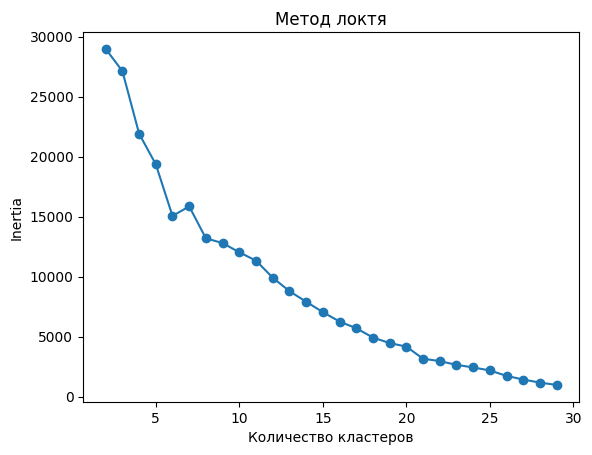

In [828]:
import matplotlib.pyplot as plt

plt.plot(range(2, 30), inertia, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.show()

Локоть находит компромисс между количеством кластеров и Inertia при k=7.

In [829]:
kmeans = KMeans(n_clusters= 5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

Добавляем кластер в `data_raw`

In [830]:
data_raw['cluster'] = clusters

In [831]:
data_raw.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Time_of_Day     3547 non-null   object
 1   Season          3547 non-null   object
 2   Type_of_coffee  3547 non-null   object
 3   cluster         3547 non-null   int32 
dtypes: int32(1), object(3)
memory usage: 97.1+ KB


In [832]:
data_raw

,Time_of_Day,Season,Type_of_coffee,cluster
0,Morning,Spring,coffee with milk,2
1,Afternoon,Spring,chocolate,1
2,Afternoon,Spring,chocolate,1
3,Afternoon,Spring,coffee,3
4,Afternoon,Spring,coffee with milk,2
...,...,...,...,...
3542,Morning,Spring,coffee with milk,2
3543,Afternoon,Spring,chocolate,1
3544,Afternoon,Spring,chocolate,1
3545,Afternoon,Spring,coffee,3


### Посмотрим на распределение данных в кластерах.

In [833]:
coffee_cluster = pd.crosstab(data_raw['cluster'], data_raw['Type_of_coffee'])
print(coffee_cluster)

# в долях
coffee_cluster_norm = pd.crosstab(data_raw['cluster'], data_raw['Type_of_coffee'], normalize='index')
print(coffee_cluster_norm)


Type_of_coffee  chocolate  coffee  coffee with milk
cluster                                            
0                       0       0               931
1                     515       0                 0
2                       0       0               756
3                       0     693                 0
4                       0       0               652
Type_of_coffee  chocolate  coffee  coffee with milk
cluster                                            
0                     0.0     0.0               1.0
1                     1.0     0.0               0.0
2                     0.0     0.0               1.0
3                     0.0     1.0               0.0
4                     0.0     0.0               1.0


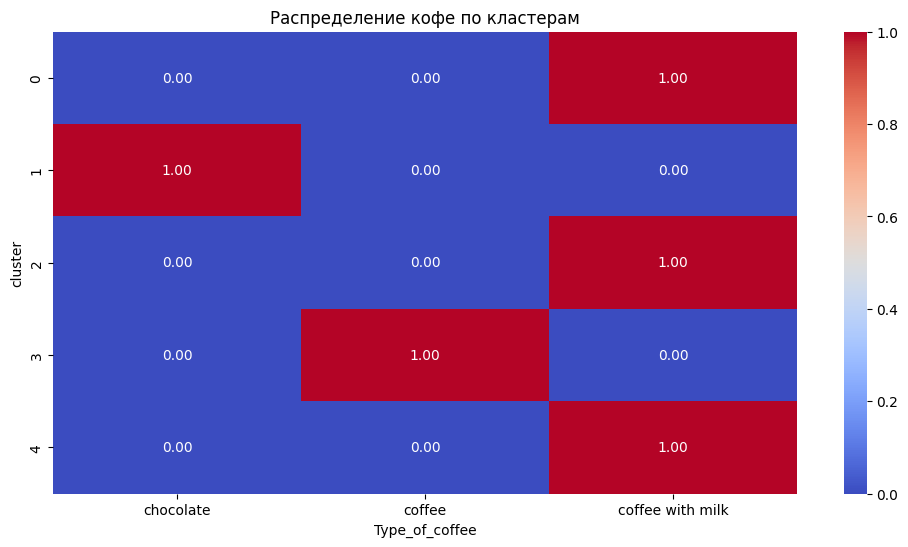

In [834]:

plt.figure(figsize=(12,6))
sns.heatmap(coffee_cluster_norm, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Распределение кофе по кластерам")
plt.show()

Заметим что распределение данных в кластерах для типов кофе приняло следующий вид.

 Кластеры содержат только 1 определенный тип кофейных напитков.

In [835]:
time_cluster = pd.crosstab(data_raw['cluster'], data_raw['Time_of_Day'], normalize='index')
print(coffee_cluster)
time_cluster_norm = pd.crosstab(data_raw['cluster'], data_raw['Time_of_Day'], normalize='index')
print(coffee_cluster_norm)

Type_of_coffee  chocolate  coffee  coffee with milk
cluster                                            
0                       0       0               931
1                     515       0                 0
2                       0       0               756
3                       0     693                 0
4                       0       0               652
Type_of_coffee  chocolate  coffee  coffee with milk
cluster                                            
0                     0.0     0.0               1.0
1                     1.0     0.0               0.0
2                     0.0     0.0               1.0
3                     0.0     1.0               0.0
4                     0.0     0.0               1.0


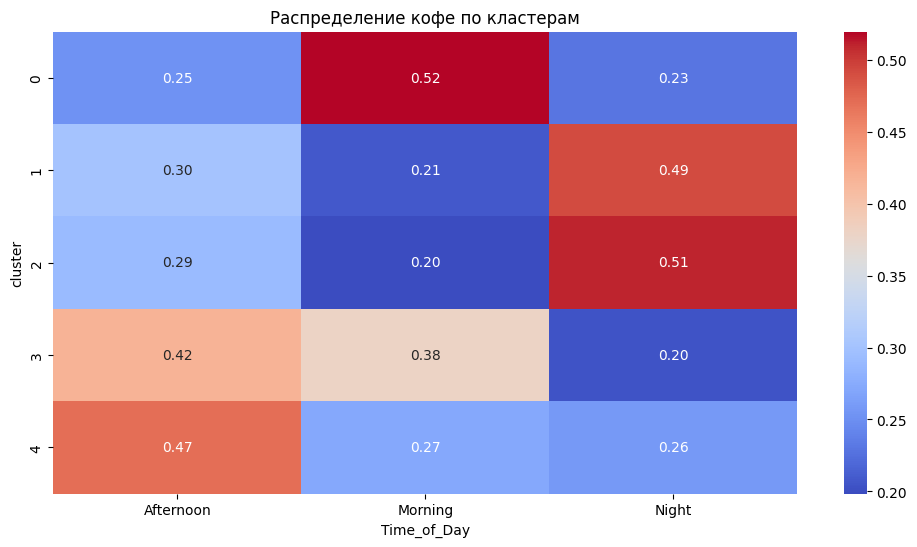

In [836]:
plt.figure(figsize=(12,6))
sns.heatmap(time_cluster_norm, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Распределение кофе по кластерам")
plt.show()

Рассмотрели распределение покупок по времени суток.

In [837]:
season_cluster = pd.crosstab(data_raw['cluster'], data_raw['Season'], normalize='index')
print(season_cluster)
season_cluster_norm = pd.crosstab(data_raw['cluster'], data_raw['Season'], normalize='index')
print(season_cluster_norm)

Season     Aurumn    Spring    Summer    Winter
cluster                                        
0        0.772288  0.000000  0.227712  0.000000
1        0.353398  0.221359  0.106796  0.318447
2        0.000000  0.730159  0.269841  0.000000
3        0.184704  0.341991  0.180375  0.292929
4        0.000000  0.000000  0.208589  0.791411
Season     Aurumn    Spring    Summer    Winter
cluster                                        
0        0.772288  0.000000  0.227712  0.000000
1        0.353398  0.221359  0.106796  0.318447
2        0.000000  0.730159  0.269841  0.000000
3        0.184704  0.341991  0.180375  0.292929
4        0.000000  0.000000  0.208589  0.791411


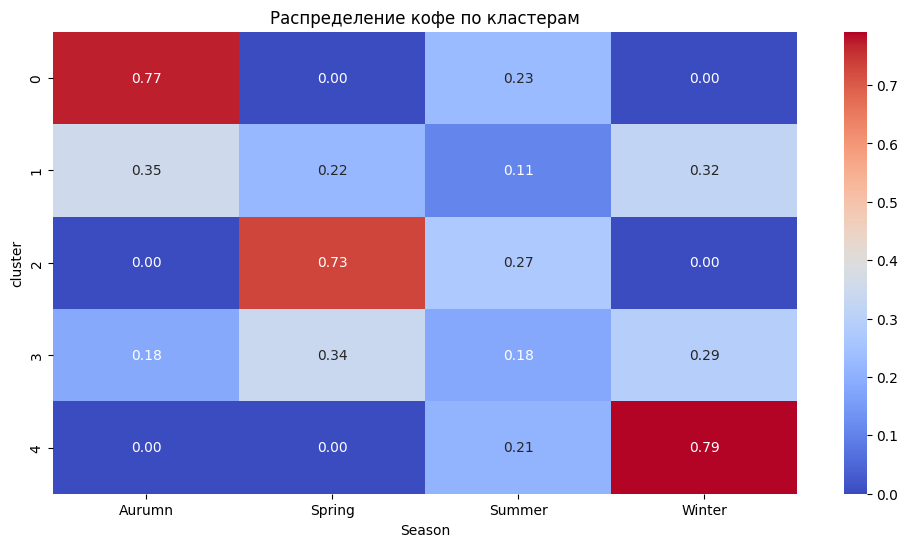

In [838]:
plt.figure(figsize=(12,6))
sns.heatmap(season_cluster_norm, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Распределение кофе по кластерам")
plt.show()

Получили распределение сезонов по кластерам.

### PCA и визуализация

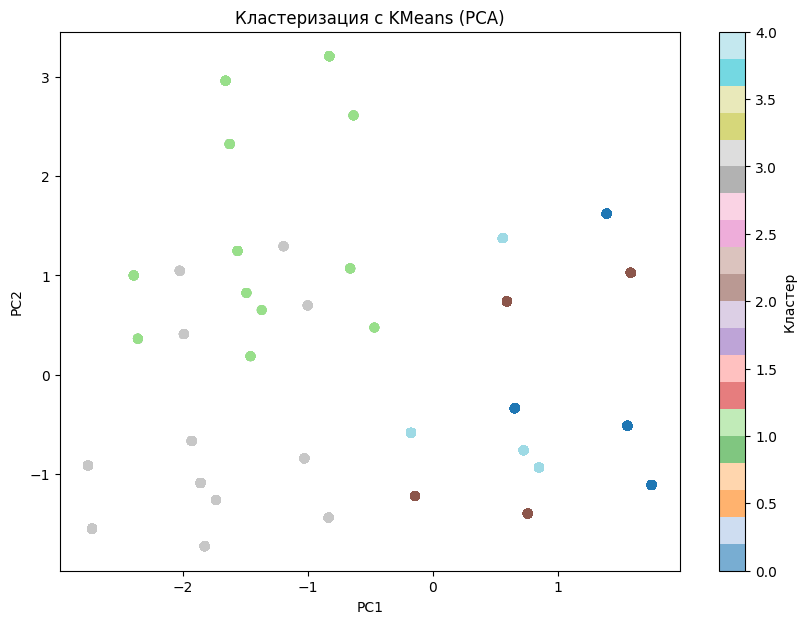

In [839]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
plt.scatter(X_pca[:,0], X_pca[:,1], c=data_raw['cluster'], cmap='tab20', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Кластеризация с KMeans (PCA)')
plt.colorbar(label='Кластер')
plt.show()

Получили 2d визуализацию.

Наличие одного практически изолированного кластера на PCA-графике(левый нижний угол) при общем пересечении остальных кластеров указывает на то, что в данных присутствует как минимум один чётко выраженный сегмент, устойчивый к понижению размерности. Остальные сегменты различимы преимущественно в более высоком измерении и частично теряют разделимость при проекции в 2D.

### Понижение размерности и визуализация

Доля объяснённой дисперсии по компонентам: [0.19264491 0.16526312]
Суммарная доля: 0.35790802823594253


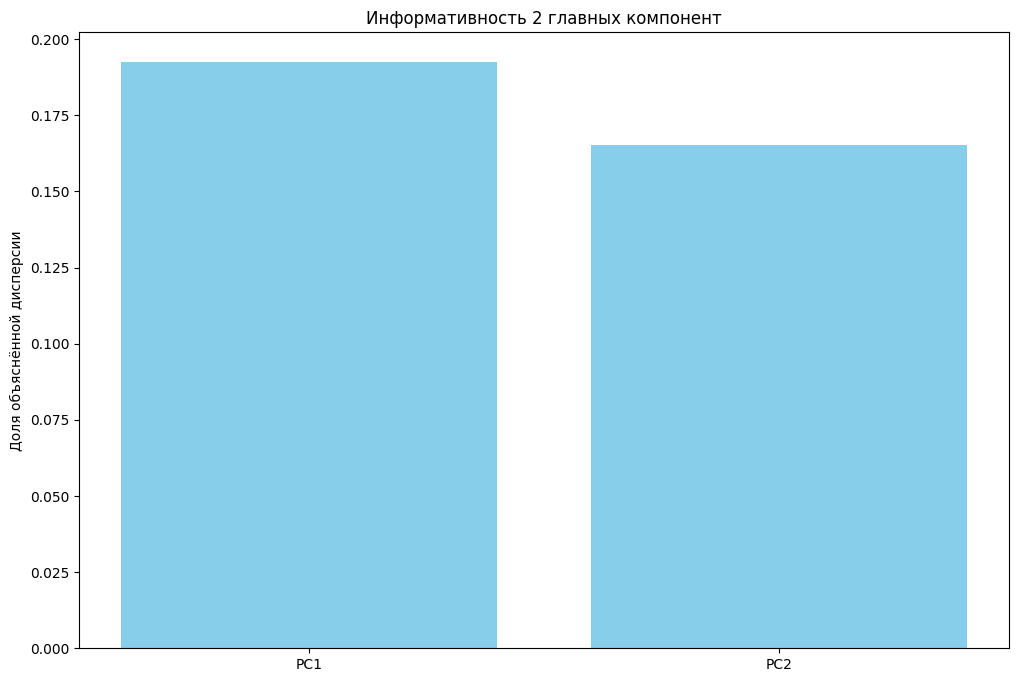

In [840]:
explained_variance = pca.explained_variance_ratio_
print("Доля объяснённой дисперсии по компонентам:", explained_variance)
print("Суммарная доля:", explained_variance.sum())

plt.figure(figsize=(12,8))
plt.bar(['PC1','PC2'], explained_variance, color='skyblue')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Информативность 2 главных компонент')
plt.show()

Первоначальные выводы для KMeans:
- При использовании PCA с n_components=2 суммарная объяснённая дисперсия составила около 35%.

- Это объясняется высокой размерностью и категориальной природой признаков (One-Hot Encoding).

- Для сохранения большей части информации требуется не менее 5 компонент, при которых сохраняется ~78% дисперсии.

- PCA в данной работе используется исключительно для визуализации, а не для обучения моделей кластеризации.

Повышение дисперсии в 2D пространстве возможна при удалении категориальных признаков, что скажется на глубине модели, и сделает её менее полезной.

Полученная суммарная доля объяснённой дисперсии (35%) для двух главных компонент является достаточно высокой, учитывая, что исходные данные представлены преимущественно категориальными признаками и были преобразованы с помощью One-Hot Encoding.

Модель сохраняет значимую часть информации и остаётся информативной, поскольку она ориентирована не на описание единичных покупок с высокой временной точностью, а на выявление общих поведенческих закономерностей.

В частности, кластеризация позволяет выделить устойчивые тенденции спроса на определённые группы напитков в зависимости от сезона и времени суток, что и являлось основной целью анализа.

# 5.2 DBSCAN
Подготовка данных

In [841]:
data_raw.drop('cluster', axis= 1, inplace= True)

In [842]:
data_raw.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Time_of_Day     3547 non-null   object
 1   Season          3547 non-null   object
 2   Type_of_coffee  3547 non-null   object
dtypes: object(3)
memory usage: 83.3+ KB


Кластеризация.

В процессе эксперементов выяснилось, что изменение esp не влияет на конечное количество кластеров и шума.

In [843]:
from sklearn.decomposition import PCA

# Используем больше 2 компонент — для корректной плотности
pca_dbscan = PCA(n_components=5)
X_pca_dbscan = pca_dbscan.fit_transform(X_scaled)

In [844]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.4, min_samples=5)
db_clusters = dbscan.fit_predict(X_pca_dbscan)

data_raw['cluster_dbscan'] = db_clusters


Число кластеров найденных DBSCAN:

In [845]:
n_clusters = len(set(db_clusters)) - (1 if -1 in db_clusters else 0)
n_noise = list(db_clusters).count(-1)

print("Число кластеров:", n_clusters)
print("Число шумовых точек:", n_noise)

Число кластеров: 36
Число шумовых точек: 0


PCA и визуализация

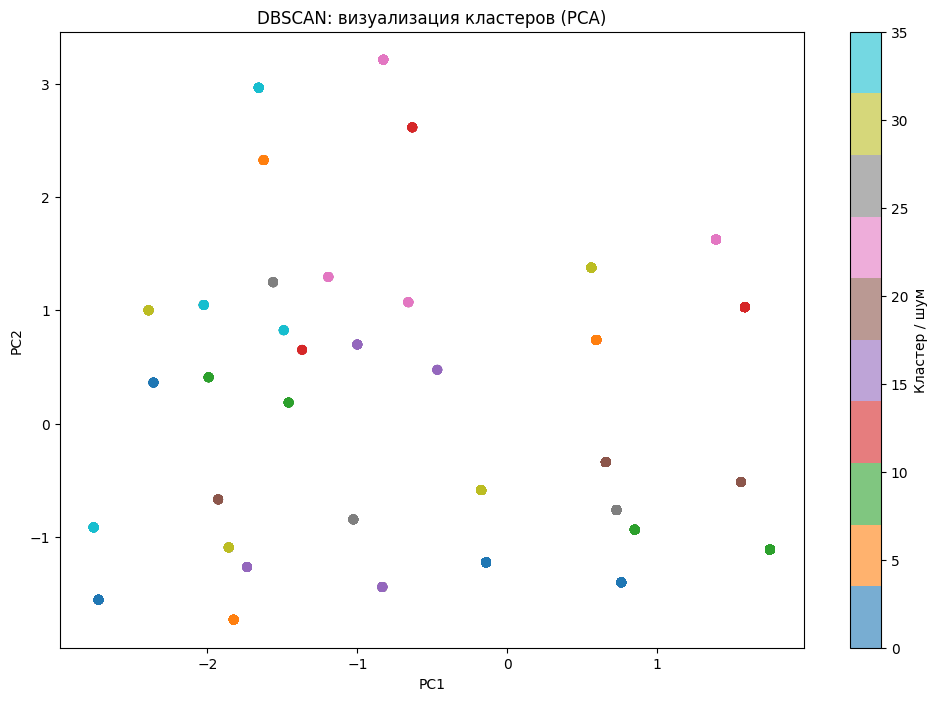

In [846]:
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(12,8))
plt.scatter(
    X_pca_vis[:, 0],
    X_pca_vis[:, 1],
    c=data_raw['cluster_dbscan'],
    cmap='tab10',
    alpha=0.6
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN: визуализация кластеров (PCA)')
plt.colorbar(label='Кластер / шум')
plt.show()

In [847]:
explained_variance = pca.explained_variance_ratio_

print("Доля объяснённой дисперсии по компонентам:")
for i, var in enumerate(explained_variance, start=1):
    print(f"PC{i}: {var:.4f}")

print("Суммарная доля объяснённой дисперсии:", explained_variance.sum())


Доля объяснённой дисперсии по компонентам:
PC1: 0.1926
PC2: 0.1653
Суммарная доля объяснённой дисперсии: 0.35790802823594253


При применении DBSCAN к данным после One-Hot Encoding алгоритм показал слабую чувствительность к параметру eps. Это связано с высокой размерностью признакового пространства, в котором расстояния между объектами становятся плохо различимыми.

Для восстановления локальной плотностной структуры данных было выполнено понижение размерности с помощью PCA. После этого DBSCAN был применён уже в пространстве главных компонент, что позволило получить интерпретируемые кластеры и корректную зависимость результата от параметров алгоритма.

Доля диспрсии осталось такой же, как и в методе KMeans

# 5.3 Agglomerative Clustering
Подготовка данных

In [849]:
data_raw

,Time_of_Day,Season,Type_of_coffee,cluster_dbscan
0,Morning,Spring,coffee with milk,0
1,Afternoon,Spring,chocolate,1
2,Afternoon,Spring,chocolate,1
3,Afternoon,Spring,coffee,2
4,Afternoon,Spring,coffee with milk,3
...,...,...,...,...
3542,Morning,Spring,coffee with milk,0
3543,Afternoon,Spring,chocolate,1
3544,Afternoon,Spring,chocolate,1
3545,Afternoon,Spring,coffee,2


In [851]:
data_raw.drop('cluster_dbscan', axis=1, inplace=True)
data_raw

,Time_of_Day,Season,Type_of_coffee
0,Morning,Spring,coffee with milk
1,Afternoon,Spring,chocolate
2,Afternoon,Spring,chocolate
3,Afternoon,Spring,coffee
4,Afternoon,Spring,coffee with milk
...,...,...,...
3542,Morning,Spring,coffee with milk
3543,Afternoon,Spring,chocolate
3544,Afternoon,Spring,chocolate
3545,Afternoon,Spring,coffee


from sklearn.preprocessing import OneHotEncoder

In [857]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering


Доля объяснённой дисперсии по компонентам:
PC1: 0.1926
PC2: 0.1653
Суммарная доля объяснённой дисперсии: 0.35790802823594015


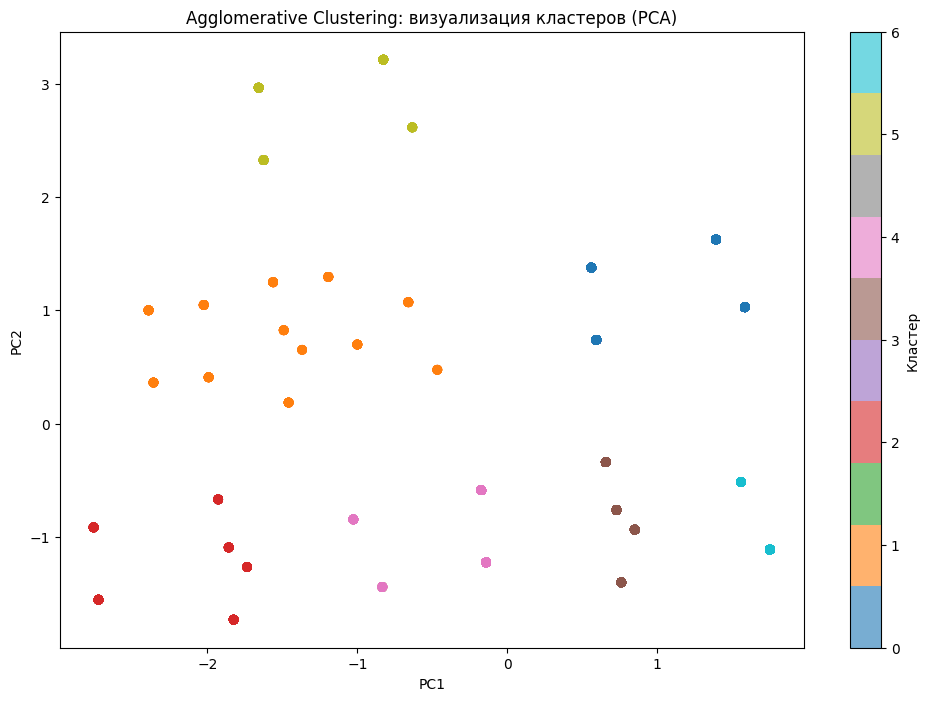

In [856]:
cat_features = ['Type_of_coffee', 'Time_of_Day', 'Season']

encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(data_raw[cat_features])

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# PCA: проекция на 2 компоненты
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Доля объяснённой дисперсии по компонентам:")
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {var:.4f}")
print("Суммарная доля объяснённой дисперсии:", pca.explained_variance_ratio_.sum())

# Агломеративная кластеризация
agglo = AgglomerativeClustering(n_clusters=7, linkage='ward')
agg_clusters = agglo.fit_predict(X_pca)
data_raw['cluster_agglo'] = agg_clusters

# Визуализация
plt.figure(figsize=(12,8))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=data_raw['cluster_agglo'],
    cmap='tab10',
    alpha=0.6
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Agglomerative Clustering: визуализация кластеров (PCA)')
plt.colorbar(label='Кластер')
plt.show()


Агломеративная кластеризация в проекции PCA на 2 компоненты дала суммарную долю объяснённой дисперсии 0.358. Это совпадает с предыдущими методами (KMeans и DBSCAN), потому что все алгоритмы работают на одинаково подготовленных данных после One-Hot Encoding и масштабирования, а проекция PCA на 2 компоненты сохраняет одинаковую структуру дисперсии.

# 6 Выводы
1. KMeans, DBSCAN и Agglomerative Clustering были применены к одним и тем же данным после One-Hot Encoding и масштабирования, с последующим сокращением размерности через PCA на 2 компоненты.

2. Для всех методов доля объяснённой дисперсии по 2 компонентам оказалась примерно 0.35–0.36, что показывает, что основная структура данных одинаково сохраняется в проекции PCA.

3. Этот процент дисперсии частично обусловлен тем, что данные категориальные, а также тем, что были удалены:
    - дублеры;

    - признаки, которые почти однозначно выражаются через другие (например, money через coffee_name и Monthsort).

4. Результаты совпали по доле дисперсии и визуальной структуре кластеров, потому что все алгоритмы работают в одном и том же числовом пространстве, где категориальные признаки корректно кодированы, а масштабирование устранило различия в диапазонах признаков.

5. Различия в распределении кластеров связаны только с механизмом самого алгоритма:
    - KMeans ищет центры кластеров;
    - DBSCAN ориентируется на плотность объектов;
    - Agglomerative Clustering строит иерархическую структуру.

6. Двумерный график PCA для Agglomerative Clustering выглядит максимально корректно разбитым, что подтверждает качество проекции и кластеризации.

**Вывод**: Все три алгоритма дают сопоставимые результаты по структуре данных в PCA, что подтверждает корректность подготовки данных и устойчивость кластеризации к выбору метода.

Используя эту модель, мы выявляем скрытые группы и зависимости в данных, получаем наглядное 2D-представление, и можем интерпретировать результаты для дальнейшего анализа данных и коррекции стратегии продаж кофейни.
Практическое применение: поведенческий анализ.